# LSEG external-time HAR base transfer

## Objective

Test whether Notebook 21's **unchanged, sentiment-free HAR volatility target**
remains a useful long/cash base in the later 2025–2026 LSEG period. Then run one
parameter-free diagnostic that keeps Gemma in scope without searching a new
strategy: aggregate Notebook 26's already-frozen exact-negative firm brakes into
a market exposure multiplier.

This is not a pristine holdout. The LSEG company-return window has already been
opened elsewhere, but this S&P 500 HAR transfer, coefficient set, and deterministic
Gemma breadth composition were fixed before their performance was computed here.

## Frozen design and gates

- **Price base:** LSEG `.SP500` adjusted open-to-open price returns. The 265-session
  series supplies causal variance warm-up; results use exactly the 167 sessions in
  the complete 44-company Gemma rectangle, 2025-10-27 through 2026-06-26.
- **HAR model:** Notebook 21's 2011–2019 control coefficients and QLIKE scale,
  without refitting. Five-session variance forecast, 10% annual target, exposure
  clipped to `[0.25, 1.00]`, 2 bps per traded side, and final liquidation.
- **Gemma modifier:** on session `t`,
  `1 - 0.75 * (# firms with strongest_event == -1) / 44`. This is the
  equal-notional market aggregate of Notebook 26's exact firm brake. There is no
  threshold, horizon, severity, or direction search.
- **Comparators:** long index; constant exposure matched to mean HAR exposure;
  and a constant multiplier matched to the Gemma overlay's mean exposure.
- **Forecast gate:** prior-22-session variance minus frozen HAR QLIKE has a
  positive 95% circular-block interval.
- **Base strategy gate:** HAR has positive net Sharpe and total return, realised
  annual volatility at most 12.5%, no worse drawdown than the long index, and
  non-negative net Sharpe in both temporal halves.
- **Gemma return gate:** overlay-minus-HAR return has BH `q < 0.05`, a positive
  interval, at least +0.10 Sharpe, and non-negative mean increment in both halves.
- **Gemma useful-risk gate:** overlay-minus-HAR downside reduction has BH
  `q < 0.05` and a positive interval, drawdown improves by at least 10%, the
  return interval is no worse than -1 bp/session, and overlay Sharpe is
  non-negative in both halves.

Return and downside are one declared two-test BH family. Timing versus the
constant-multiplier comparator is secondary mechanism evidence. No result in
this opened window can promote a sentiment strategy.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    CONTROL_FEATURES,
    LogVarianceModel,
    VolatilityTargetConfig,
    backtest_single_asset_exposure,
    build_volatility_frame,
    build_volatility_target_exposure,
    paired_circular_block_mean,
    predict_variance,
    qlike_loss,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260805
CONFIG = VolatilityTargetConfig(random_seed=SEED)
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
N_FIRMS = 44
BRAKE_EXPOSURE = 0.25

OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/46_lseg_external_time_har_base_transfer"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_sp500_20250620_20260710.csv"
PRICE_MANIFEST_PATH = PRICE_PATH.with_suffix(".manifest.json")
GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
COEFFICIENT_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/21_fnspid_sentiment_volatility_target"
    / "model_coefficients.csv"
)
NOTEBOOK21_MANIFEST_PATH = COEFFICIENT_PATH.with_name("manifest.json")
NOTEBOOK26_MANIFEST_PATH = (
    REPO_ROOT / "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/manifest.json"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")
print(f"seed:   {SEED}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/46_lseg_external_time_har_base_transfer
seed:   20260805


In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def bh_qvalues(p_values: list[float]) -> np.ndarray:
    values = np.asarray(p_values, dtype=float)
    if np.any(~np.isfinite(values)) or np.any((values < 0) | (values > 1)):
        raise ValueError("BH p-values must be finite and in [0, 1]")
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0.0, 1.0)
    return adjusted


def annualized_sharpe(values: pd.Series) -> float:
    array = values.to_numpy(dtype=float)
    volatility = float(np.std(array, ddof=1)) if len(array) > 1 else 0.0
    return (
        float(np.sqrt(252) * np.mean(array) / volatility)
        if volatility > 0 and math.isfinite(volatility)
        else float("nan")
    )


def max_drawdown(values: pd.Series) -> float:
    equity = (1.0 + values).cumprod().to_numpy(dtype=float)
    peak = np.maximum.accumulate(equity)
    return float(np.min(equity / peak - 1.0))


def paired_estimands(
    challenger: pd.DataFrame,
    baseline: pd.DataFrame,
    *,
    comparison: str,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    paired = (
        challenger[["session_date", "net_return"]]
        .rename(columns={"net_return": "challenger_net"})
        .merge(
            baseline[["session_date", "net_return"]].rename(
                columns={"net_return": "baseline_net"}
            ),
            on="session_date",
            validate="1:1",
        )
        .sort_values("session_date", kind="mergesort")
        .reset_index(drop=True)
    )
    paired["net_difference"] = paired["challenger_net"] - paired["baseline_net"]
    paired["downside_reduction"] = (
        np.minimum(paired["baseline_net"], 0.0) ** 2
        - np.minimum(paired["challenger_net"], 0.0) ** 2
    )
    rows = []
    for offset, (estimand, column) in enumerate(
        (
            ("challenger minus baseline net return", "net_difference"),
            ("baseline minus challenger downside squared return", "downside_reduction"),
        )
    ):
        result = paired_circular_block_mean(
            paired[column],
            block_length=CONFIG.bootstrap_block_length,
            replications=CONFIG.bootstrap_replications,
            seed=seed + offset,
        )
        rows.append({"comparison": comparison, "estimand": estimand, **result})
    return pd.DataFrame(rows), paired

## Input contract and feasibility

Only the aggregate Gemma firm-open panel is loaded; no headline text is read or
emitted. The price manifest, Notebook 21 coefficient artifact, and Notebook 26
manifest are hashed into this run.

In [3]:
required_paths = (
    PRICE_PATH,
    PRICE_MANIFEST_PATH,
    GEMMA_PATH,
    COEFFICIENT_PATH,
    NOTEBOOK21_MANIFEST_PATH,
    NOTEBOOK26_MANIFEST_PATH,
)
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"missing required inputs: {missing_paths}")

price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
if price_manifest["file"]["sha256"] != sha256(PRICE_PATH):
    raise ValueError("S&P 500 price file does not match its manifest")
if price_manifest.get("ric") != ".SP500":
    raise ValueError("expected the LSEG .SP500 index series")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = prices["session_date"].dt.normalize()
prices = prices.sort_values("session_date", kind="mergesort").reset_index(drop=True)
if prices["session_date"].duplicated().any():
    raise ValueError("duplicate index price sessions")
if prices["open"].isna().any() or prices["open"].le(0).any():
    raise ValueError("index opens must be finite and positive")
prices["gross_return"] = prices["open"].shift(-1) / prices["open"] - 1.0

gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
symbols_per_session = gemma.groupby("session_date")["symbol"].nunique()
if not symbols_per_session.eq(N_FIRMS).all():
    raise ValueError("Gemma input is not a complete 44-company rectangle")
lseg_sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))

firm_flags = gemma.assign(
    exact_negative=np.isclose(
        gemma["strongest_event"].to_numpy(dtype=float),
        -1.0,
        atol=1e-12,
        rtol=0.0,
        equal_nan=False,
    )
)
flag_counts = (
    firm_flags.groupby("session_date")["exact_negative"]
    .sum()
    .reindex(lseg_sessions, fill_value=0)
    .astype(int)
)
gemma_modifier = 1.0 - (1.0 - BRAKE_EXPOSURE) * flag_counts / N_FIRMS

pressure_placeholder = prices[["session_date"]].assign(negative_pressure_z=0.0)
volatility_frame = build_volatility_frame(
    prices[["session_date", "gross_return"]],
    pressure_placeholder,
    config=CONFIG,
)

coefficient_table = pd.read_csv(COEFFICIENT_PATH)
control_row = coefficient_table.set_index("arm").loc["control_har"]
if tuple(CONTROL_FEATURES) != (
    "log_var_daily",
    "log_var_weekly",
    "log_var_monthly",
):
    raise RuntimeError("unexpected HAR feature contract")
control_model = LogVarianceModel(
    feature_names=tuple(CONTROL_FEATURES),
    intercept=float(control_row["intercept"]),
    coefficients=tuple(float(control_row[name]) for name in CONTROL_FEATURES),
    qlike_scale=float(control_row["qlike_scale"]),
    n_train=int(control_row["n_train"]),
)
har_forecast = predict_variance(volatility_frame, control_model)

decision_mask = volatility_frame["session_date"].isin(lseg_sessions)
decision = volatility_frame.loc[decision_mask].copy()
decision["har_forecast"] = har_forecast.loc[decision.index]
if len(decision) != len(lseg_sessions):
    raise ValueError("index series does not cover every LSEG decision session")
if decision[["forward_return", "har_forecast"]].isna().any().any():
    raise ValueError("incomplete next-open return or HAR forecast in the LSEG window")

input_audit = pd.DataFrame(
    [
        {
            "price_sessions": len(prices),
            "price_first": prices["session_date"].min(),
            "price_last": prices["session_date"].max(),
            "lseg_sessions": len(lseg_sessions),
            "lseg_first": lseg_sessions.min(),
            "lseg_last": lseg_sessions.max(),
            "complete_har_forecasts": int(decision["har_forecast"].notna().sum()),
            "next_open_returns": int(decision["forward_return"].notna().sum()),
            "gemma_rows": len(gemma),
            "symbols": gemma["symbol"].nunique(),
            "flagged_firm_sessions": int(flag_counts.sum()),
            "flagged_dates": int(flag_counts.gt(0).sum()),
            "modifier_min": float(gemma_modifier.min()),
            "modifier_mean": float(gemma_modifier.mean()),
            "headline_text_loaded": False,
        }
    ]
)
display(input_audit)

,price_sessions,price_first,price_last,lseg_sessions,lseg_first,lseg_last,complete_har_forecasts,next_open_returns,gemma_rows,symbols,flagged_firm_sessions,flagged_dates,modifier_min,modifier_mean,headline_text_loaded
0,265,2025-06-20,2026-07-10,167,2025-10-27,2026-06-26,167,167,7348,44,143,99,0.931818,0.985404,False


## Frozen forecasts and exposure paths

In [4]:
har_exposure = build_volatility_target_exposure(
    decision,
    decision["har_forecast"],
    config=CONFIG,
    arm="frozen_har",
)
long_exposure = pd.DataFrame(
    {
        "session_date": decision["session_date"].to_numpy(),
        "arm": "long_index",
        "forecast_variance": np.nan,
        "forecast_annual_volatility": np.nan,
        "exposure": 1.0,
    }
)
constant_har_exposure = pd.DataFrame(
    {
        "session_date": decision["session_date"].to_numpy(),
        "arm": "constant_matched_har",
        "forecast_variance": np.nan,
        "forecast_annual_volatility": np.nan,
        "exposure": float(har_exposure["exposure"].mean()),
    }
)

modifier_frame = pd.DataFrame(
    {
        "session_date": lseg_sessions,
        "exact_negative_firms": flag_counts.to_numpy(dtype=int),
        "gemma_modifier": gemma_modifier.to_numpy(dtype=float),
    }
)
overlay_exposure = har_exposure.merge(
    modifier_frame,
    on="session_date",
    validate="1:1",
)
overlay_exposure["base_exposure"] = overlay_exposure["exposure"]
overlay_exposure["exposure"] = (
    overlay_exposure["base_exposure"] * overlay_exposure["gemma_modifier"]
)
overlay_exposure["arm"] = "har_gemma_breadth_overlay"

constant_modifier = float(
    overlay_exposure["exposure"].mean() / har_exposure["exposure"].mean()
)
constant_overlay_exposure = har_exposure.copy()
constant_overlay_exposure["exposure"] *= constant_modifier
constant_overlay_exposure["arm"] = "har_constant_gemma_multiplier"

exposure_audit = pd.DataFrame(
    [
        {
            "arm": name,
            "sessions": len(frame),
            "mean_exposure": float(frame["exposure"].mean()),
            "minimum_exposure": float(frame["exposure"].min()),
            "maximum_exposure": float(frame["exposure"].max()),
            "changed_sessions": int(
                (~np.isclose(
                    frame["exposure"].to_numpy(dtype=float),
                    har_exposure["exposure"].to_numpy(dtype=float),
                )).sum()
            )
            if name.startswith("har_") and name != "frozen_har"
            else 0,
        }
        for name, frame in (
            ("long_index", long_exposure),
            ("constant_matched_har", constant_har_exposure),
            ("frozen_har", har_exposure),
            ("har_constant_gemma_multiplier", constant_overlay_exposure),
            ("har_gemma_breadth_overlay", overlay_exposure),
        )
    ]
)
if not overlay_exposure["exposure"].between(0.0, 1.0).all():
    raise ValueError("Gemma overlay exposure left [0, 1]")
if not np.isclose(
    overlay_exposure["exposure"].mean(),
    constant_overlay_exposure["exposure"].mean(),
    atol=1e-15,
):
    raise ValueError("constant Gemma comparator is not exposure matched")
display(exposure_audit)

,arm,sessions,mean_exposure,minimum_exposure,maximum_exposure,changed_sessions
0,long_index,167,1.000000,1.000000,1.000000,0
1,constant_matched_har,167,0.720850,0.720850,0.720850,0
2,frozen_har,167,0.720850,0.464452,1.000000,0
3,har_constant_gemma_multiplier,167,0.710599,0.457847,0.985778,167
4,har_gemma_breadth_overlay,167,0.710599,0.456536,1.000000,99


## External-time forecast and strategy results

In [5]:
forecast_eval = decision.loc[
    decision["realized_variance_forward"].notna(),
    ["session_date", "realized_variance_forward", "har_forecast", "log_var_monthly"],
].copy()
forecast_eval["naive_monthly_forecast"] = np.exp(forecast_eval["log_var_monthly"])
forecast_eval["qlike_har"] = qlike_loss(
    forecast_eval["realized_variance_forward"].to_numpy(dtype=float),
    forecast_eval["har_forecast"].to_numpy(dtype=float),
)
forecast_eval["qlike_naive"] = qlike_loss(
    forecast_eval["realized_variance_forward"].to_numpy(dtype=float),
    forecast_eval["naive_monthly_forecast"].to_numpy(dtype=float),
)
forecast_eval["qlike_improvement"] = (
    forecast_eval["qlike_naive"] - forecast_eval["qlike_har"]
)
forecast_test = paired_circular_block_mean(
    forecast_eval["qlike_improvement"],
    block_length=CONFIG.bootstrap_block_length,
    replications=CONFIG.bootstrap_replications,
    seed=SEED,
)
forecast_metrics = pd.DataFrame(
    [
        {
            "model": "naive_prior_22_variance",
            "n_targets": len(forecast_eval),
            "mean_qlike": float(forecast_eval["qlike_naive"].mean()),
            "forecast_actual_spearman": float(
                forecast_eval[["naive_monthly_forecast", "realized_variance_forward"]]
                .corr(method="spearman")
                .iloc[0, 1]
            ),
        },
        {
            "model": "frozen_har_2011_2019",
            "n_targets": len(forecast_eval),
            "mean_qlike": float(forecast_eval["qlike_har"].mean()),
            "forecast_actual_spearman": float(
                forecast_eval[["har_forecast", "realized_variance_forward"]]
                .corr(method="spearman")
                .iloc[0, 1]
            ),
        },
    ]
)
forecast_inference = pd.DataFrame(
    [{"estimand": "naive minus frozen HAR QLIKE", **forecast_test}]
)
display(forecast_metrics)
display(forecast_inference)

returns = decision[["session_date", "forward_return"]]
exposures = {
    "long_index": long_exposure,
    "constant_matched_har": constant_har_exposure,
    "frozen_har": har_exposure,
    "har_constant_gemma_multiplier": constant_overlay_exposure,
    "har_gemma_breadth_overlay": overlay_exposure,
}
daily_paths = {
    arm: backtest_single_asset_exposure(
        returns,
        exposure,
        cost_bps_per_side=CONFIG.cost_bps_per_side,
    )
    for arm, exposure in exposures.items()
}
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_weight_backtest(path, config=CONFIG)}
        for arm, path in daily_paths.items()
    ]
)
display(
    results[
        [
            "arm",
            "n_sessions",
            "mean_gross_exposure",
            "sharpe_gross",
            "sharpe_net",
            "ann_vol_net",
            "total_return_net",
            "max_drawdown",
            "annualized_turnover",
        ]
    ]
)

,model,n_targets,mean_qlike,forecast_actual_spearman
0,naive_prior_22_variance,167,-8.453407,0.131966
1,frozen_har_2011_2019,167,-8.478178,0.198259


,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,naive minus frozen HAR QLIKE,167,0.024771,-0.025895,0.079526,0.360800,20,4999,20260805


,arm,n_sessions,mean_gross_exposure,sharpe_gross,sharpe_net,ann_vol_net,total_return_net,max_drawdown,annualized_turnover
0,long_index,167,1.000000,0.944412,0.940173,0.135987,0.081789,-0.090974,1.508982
1,constant_matched_har,167,0.720850,0.944412,0.940173,0.098026,0.059609,-0.066130,1.087750
2,frozen_har,167,0.720850,0.271602,0.239561,0.097450,0.012411,-0.077704,7.828610
3,har_constant_gemma_multiplier,167,0.710599,0.271602,0.239561,0.096064,0.012278,-0.076627,7.717272
4,har_gemma_breadth_overlay,167,0.710599,0.278233,0.246584,0.096031,0.012728,-0.076619,7.623870


In [6]:
har_inference, har_pair = paired_estimands(
    daily_paths["frozen_har"],
    daily_paths["constant_matched_har"],
    comparison="frozen_har_vs_constant_matched_har",
    seed=SEED + 10,
)
overlay_inference, overlay_pair = paired_estimands(
    daily_paths["har_gemma_breadth_overlay"],
    daily_paths["frozen_har"],
    comparison="gemma_overlay_vs_frozen_har",
    seed=SEED + 20,
)
timing_inference, timing_pair = paired_estimands(
    daily_paths["har_gemma_breadth_overlay"],
    daily_paths["har_constant_gemma_multiplier"],
    comparison="gemma_overlay_vs_constant_multiplier",
    seed=SEED + 30,
)

overlay_q = bh_qvalues(overlay_inference["p_two_sided"].tolist())
overlay_inference["q_bh_two_test"] = overlay_q
overlay_inference["bh_reject_q05"] = overlay_inference["q_bh_two_test"].lt(0.05)
all_inference = pd.concat(
    [har_inference, overlay_inference, timing_inference],
    ignore_index=True,
)
display(all_inference)

midpoint = len(lseg_sessions) // 2
half_ranges = (
    ("first_half", lseg_sessions[0], lseg_sessions[midpoint - 1]),
    ("second_half", lseg_sessions[midpoint], lseg_sessions[-1]),
)
half_rows = []
for period, start, end in half_ranges:
    for arm, path in daily_paths.items():
        part = path.loc[path["session_date"].between(start, end)]
        half_rows.append(
            {
                "period": period,
                "arm": arm,
                "start": start,
                "end": end,
                "n_sessions": len(part),
                "sharpe_net": annualized_sharpe(part["net_return"]),
                "mean_net_bps_session": float(part["net_return"].mean() * 10_000),
                "total_return_net": float((1.0 + part["net_return"]).prod() - 1.0),
                "max_drawdown": max_drawdown(part["net_return"]),
            }
        )
temporal_results = pd.DataFrame(half_rows)

incremental_halves = (
    overlay_pair.assign(
        period=np.where(
            overlay_pair["session_date"].le(lseg_sessions[midpoint - 1]),
            "first_half",
            "second_half",
        )
    )
    .groupby("period", as_index=False)
    .agg(
        n_sessions=("session_date", "size"),
        overlay_minus_har_bps_session=("net_difference", lambda x: float(x.mean() * 10_000)),
        downside_reduction_bps2_session=(
            "downside_reduction",
            lambda x: float(x.mean() * 100_000_000),
        ),
    )
)
display(temporal_results)
display(incremental_halves)

,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05
0,frozen_har_vs_constant_matched_har,challenger minus baseline net return,167,-0.000273,-0.000439,-0.000136,0.002600,20,4999,20260815,NaN,NaN
1,frozen_har_vs_constant_matched_har,baseline minus challenger downside squared return,167,-0.000003,-0.000007,0.000001,0.116000,20,4999,20260816,NaN,NaN
2,gemma_overlay_vs_frozen_har,challenger minus baseline net return,167,0.000001,-0.000016,0.000019,0.891000,20,4999,20260825,0.891000,False
3,gemma_overlay_vs_frozen_har,baseline minus challenger downside squared return,167,0.000001,0.000000,0.000001,0.012200,20,4999,20260826,0.024400,True
4,gemma_overlay_vs_constant_multiplier,challenger minus baseline net return,167,0.000003,-0.000008,0.000014,0.635800,20,4999,20260835,NaN,NaN
5,gemma_overlay_vs_constant_multiplier,baseline minus challenger downside squared return,167,0.000000,-0.000000,0.000000,0.821800,20,4999,20260836,NaN,NaN


,period,arm,start,end,n_sessions,sharpe_net,mean_net_bps_session,total_return_net,max_drawdown
0,first_half,long_index,2025-10-27,2026-02-25,83,0.178773,0.841480,0.004702,-0.051100
1,first_half,constant_matched_har,2025-10-27,2026-02-25,83,0.178773,0.606581,0.003851,-0.036976
2,first_half,frozen_har,2025-10-27,2026-02-25,83,-0.519442,-1.904138,-0.017051,-0.038976
3,first_half,har_constant_gemma_multiplier,2025-10-27,2026-02-25,83,-0.519442,-1.877057,-0.016792,-0.038428
4,first_half,har_gemma_breadth_overlay,2025-10-27,2026-02-25,83,-0.518284,-1.880641,-0.016832,-0.038652
5,second_half,long_index,2026-02-26,2026-06-26,84,1.538022,9.255059,0.076726,-0.078164
6,second_half,constant_matched_har,2026-02-26,2026-06-26,84,1.538022,6.671514,0.055544,-0.056788
7,second_half,frozen_har,2026-02-26,2026-06-26,84,0.914675,3.723234,0.029974,-0.055944
8,second_half,har_constant_gemma_multiplier,2026-02-26,2026-06-26,84,0.914675,3.670282,0.029566,-0.055164
9,second_half,har_gemma_breadth_overlay,2026-02-26,2026-06-26,84,0.932395,3.726404,0.030066,-0.055253


,period,n_sessions,overlay_minus_har_bps_session,downside_reduction_bps2_session
0,first_half,83,0.023497,41.622437
1,second_half,84,0.003170,86.810756


In [7]:
cost_rows = []
for cost_bps in COST_GRID:
    for arm, path in daily_paths.items():
        repriced = reprice_daily(path, cost_bps_per_side=cost_bps)
        summary = summarize_weight_backtest(repriced, config=CONFIG)
        cost_rows.append(
            {
                "cost_bps_per_side": cost_bps,
                "arm": arm,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)

result_index = results.set_index("arm")
long_result = result_index.loc["long_index"]
har_result = result_index.loc["frozen_har"]
overlay_result = result_index.loc["har_gemma_breadth_overlay"]

forecast_transfer_gate = bool(forecast_test["ci_low"] > 0)
har_half_sharpes = temporal_results.loc[
    temporal_results["arm"].eq("frozen_har"), "sharpe_net"
]
base_strategy_quality_gate = bool(
    har_result["sharpe_net"] > 0
    and har_result["total_return_net"] > 0
    and har_result["ann_vol_net"] <= 0.125
    and abs(har_result["max_drawdown"]) <= abs(long_result["max_drawdown"])
    and har_half_sharpes.ge(0).all()
)
external_time_base_gate = bool(forecast_transfer_gate and base_strategy_quality_gate)

overlay_return_test = overlay_inference.loc[
    overlay_inference["estimand"].eq("challenger minus baseline net return")
].iloc[0]
overlay_downside_test = overlay_inference.loc[
    overlay_inference["estimand"].eq(
        "baseline minus challenger downside squared return"
    )
].iloc[0]
overlay_sharpe_improvement = float(
    overlay_result["sharpe_net"] - har_result["sharpe_net"]
)
overlay_drawdown_improvement = float(
    (abs(har_result["max_drawdown"]) - abs(overlay_result["max_drawdown"]))
    / abs(har_result["max_drawdown"])
)
overlay_half_sharpes = temporal_results.loc[
    temporal_results["arm"].eq("har_gemma_breadth_overlay"), "sharpe_net"
]
overlay_return_gate = bool(
    overlay_return_test["q_bh_two_test"] < 0.05
    and overlay_return_test["ci_low"] > 0
    and overlay_sharpe_improvement >= 0.10
    and incremental_halves["overlay_minus_har_bps_session"].ge(0).all()
)
overlay_useful_risk_gate = bool(
    overlay_downside_test["q_bh_two_test"] < 0.05
    and overlay_downside_test["ci_low"] > 0
    and overlay_drawdown_improvement >= 0.10
    and overlay_return_test["ci_low"] > -0.0001
    and overlay_half_sharpes.ge(0).all()
)

gates = pd.DataFrame(
    [
        {
            "forecast_transfer_gate": forecast_transfer_gate,
            "base_strategy_quality_gate": base_strategy_quality_gate,
            "external_time_base_gate": external_time_base_gate,
            "har_net_sharpe": float(har_result["sharpe_net"]),
            "har_total_return_net": float(har_result["total_return_net"]),
            "har_ann_vol_net": float(har_result["ann_vol_net"]),
            "har_max_drawdown": float(har_result["max_drawdown"]),
            "long_index_max_drawdown": float(long_result["max_drawdown"]),
            "overlay_sharpe_improvement": overlay_sharpe_improvement,
            "overlay_drawdown_relative_improvement": overlay_drawdown_improvement,
            "overlay_return_gate": overlay_return_gate,
            "overlay_useful_risk_gate": overlay_useful_risk_gate,
        }
    ]
)
display(cost_curve)
display(gates)

,cost_bps_per_side,arm,sharpe_net,total_return_net,max_drawdown
0,0.000000,long_index,0.944412,0.082219,-0.090974
1,0.000000,constant_matched_har,0.944412,0.059913,-0.066130
2,0.000000,frozen_har,0.271602,0.014512,-0.077127
3,0.000000,har_constant_gemma_multiplier,0.271602,0.014349,-0.076058
4,0.000000,har_gemma_breadth_overlay,0.278233,0.014774,-0.076064
5,1.000000,long_index,0.942293,0.082004,-0.090974
6,1.000000,constant_matched_har,0.942293,0.059761,-0.066130
7,1.000000,frozen_har,0.255584,0.013461,-0.077415
8,1.000000,har_constant_gemma_multiplier,0.255584,0.013313,-0.076342
9,1.000000,har_gemma_breadth_overlay,0.262412,0.013750,-0.076341


,forecast_transfer_gate,base_strategy_quality_gate,external_time_base_gate,har_net_sharpe,har_total_return_net,har_ann_vol_net,har_max_drawdown,long_index_max_drawdown,overlay_sharpe_improvement,overlay_drawdown_relative_improvement,overlay_return_gate,overlay_useful_risk_gate
0,False,False,False,0.239561,0.012411,0.097450,-0.077704,-0.090974,0.007023,0.013959,False,False


## Figures

findfont: Failed to find font weight medium, now using 400.


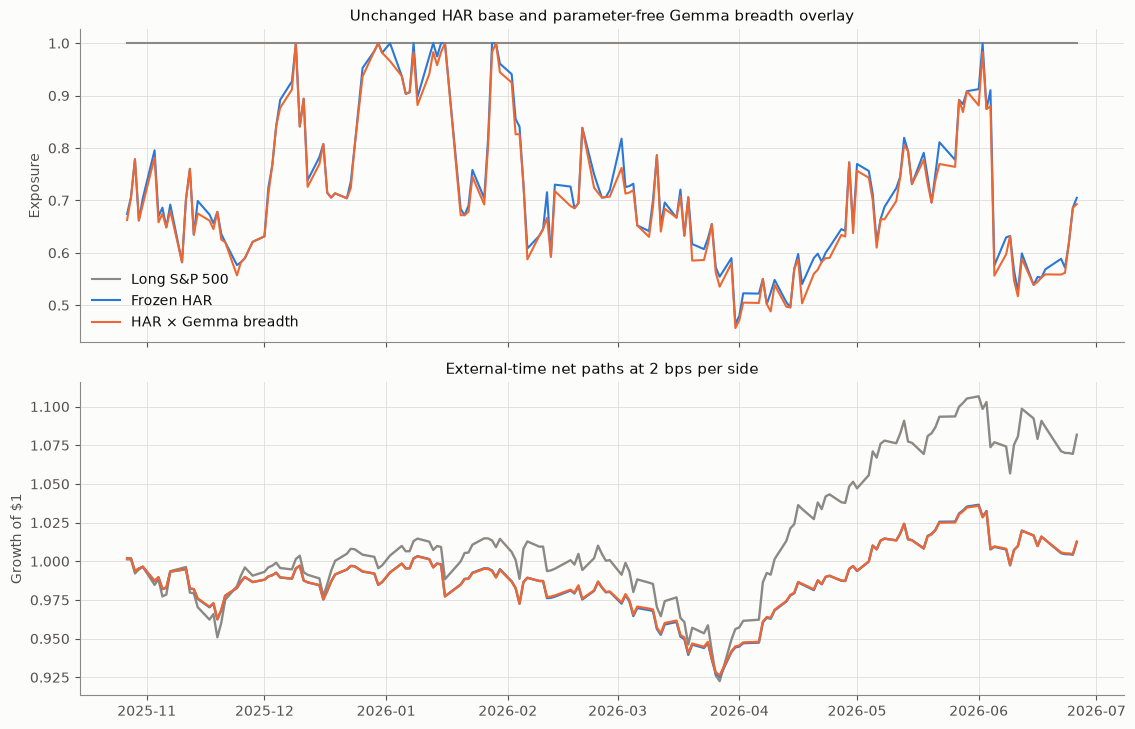

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.4), sharex=True)
for arm, label, colour in (
    ("long_index", "Long S&P 500", INK["muted"]),
    ("frozen_har", "Frozen HAR", CATEGORICAL[0]),
    ("har_gemma_breadth_overlay", "HAR × Gemma breadth", CATEGORICAL[1]),
):
    path = daily_paths[arm]
    exposure = exposures[arm]
    axes[0].plot(
        exposure["session_date"],
        exposure["exposure"],
        label=label,
        color=colour,
        linewidth=1.5,
    )
    axes[1].plot(
        path["session_date"],
        (1.0 + path["net_return"]).cumprod(),
        label=label,
        color=colour,
        linewidth=1.7,
    )
axes[0].set_ylabel("Exposure")
axes[0].set_title("Unchanged HAR base and parameter-free Gemma breadth overlay")
axes[0].legend(loc="lower left")
axes[1].set_ylabel("Growth of $1")
axes[1].set_title("External-time net paths at 2 bps per side")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_equity.png", dpi=170, bbox_inches="tight")
plt.show()

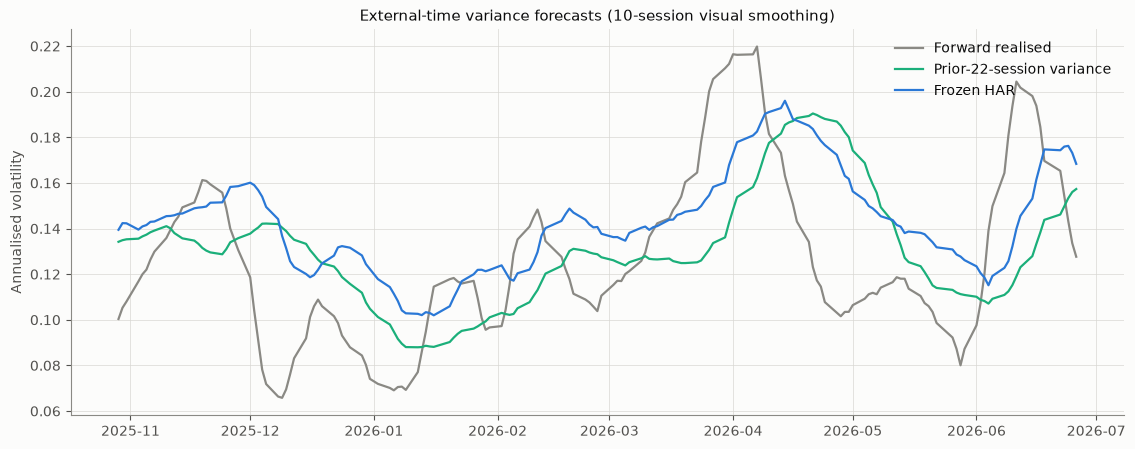

In [9]:
plot_forecast = forecast_eval.copy()
plot_forecast["realized_annual_vol"] = np.sqrt(
    plot_forecast["realized_variance_forward"] * 252
)
plot_forecast["har_annual_vol"] = np.sqrt(plot_forecast["har_forecast"] * 252)
plot_forecast["naive_annual_vol"] = np.sqrt(
    plot_forecast["naive_monthly_forecast"] * 252
)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
for column, label, colour in (
    ("realized_annual_vol", "Forward realised", INK["muted"]),
    ("naive_annual_vol", "Prior-22-session variance", CATEGORICAL[2]),
    ("har_annual_vol", "Frozen HAR", CATEGORICAL[0]),
):
    series = plot_forecast.set_index("session_date")[column].rolling(10, min_periods=3).mean()
    ax.plot(series.index, series, label=label, color=colour, linewidth=1.6)
ax.set_ylabel("Annualised volatility")
ax.set_title("External-time variance forecasts (10-session visual smoothing)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "forecast_transfer.png", dpi=170, bbox_inches="tight")
plt.show()

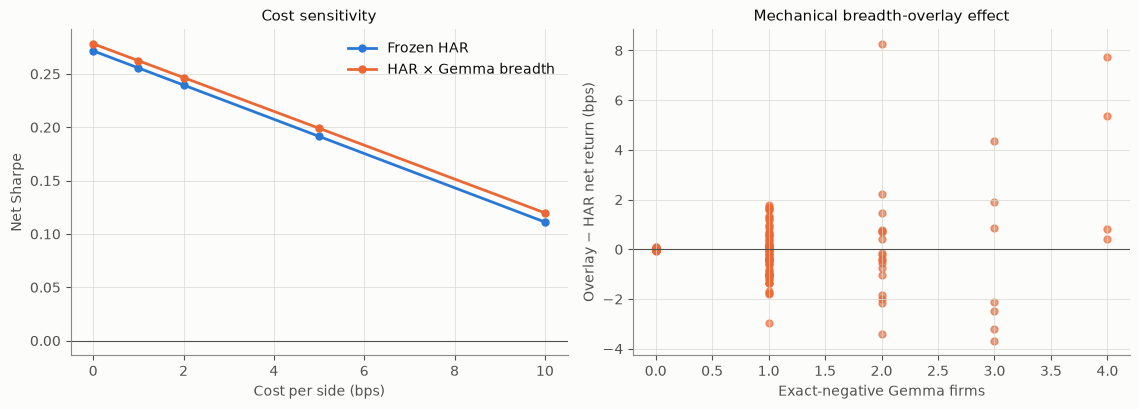

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for arm, label, colour in (
    ("frozen_har", "Frozen HAR", CATEGORICAL[0]),
    ("har_gemma_breadth_overlay", "HAR × Gemma breadth", CATEGORICAL[1]),
):
    part = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[0].plot(
        part["cost_bps_per_side"],
        part["sharpe_net"],
        marker="o",
        label=label,
        color=colour,
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xlabel("Cost per side (bps)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")

axes[1].scatter(
    modifier_frame["exact_negative_firms"],
    overlay_pair["net_difference"] * 10_000,
    alpha=0.65,
    color=CATEGORICAL[1],
)
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Exact-negative Gemma firms")
axes[1].set_ylabel("Overlay − HAR net return (bps)")
axes[1].set_title("Mechanical breadth-overlay effect")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_gemma_increment.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [11]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
coefficient_table.to_csv(OUTPUT_DIR / "frozen_model_coefficients.csv", index=False)
modifier_frame.to_csv(OUTPUT_DIR / "gemma_breadth_modifier.csv", index=False)
exposure_audit.to_csv(OUTPUT_DIR / "exposure_audit.csv", index=False)
forecast_metrics.to_csv(OUTPUT_DIR / "forecast_metrics.csv", index=False)
forecast_inference.to_csv(OUTPUT_DIR / "forecast_inference.csv", index=False)
forecast_eval.to_parquet(OUTPUT_DIR / "forecast_evaluation.parquet", index=False)
results.to_csv(OUTPUT_DIR / "strategy_results.csv", index=False)
all_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
temporal_results.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
incremental_halves.to_csv(OUTPUT_DIR / "incremental_halves.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, path in daily_paths.items():
    path.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

if external_time_base_gate:
    base_verdict = "The frozen HAR base passes its external-time forecast and strategy gates."
elif base_strategy_quality_gate:
    base_verdict = "HAR passes the strategy-quality gate but not the forecast-transfer gate."
else:
    base_verdict = "HAR does not pass the full external-time base gate."

if overlay_return_gate:
    overlay_verdict = "The Gemma breadth overlay passes the exploratory return gate."
elif overlay_useful_risk_gate:
    overlay_verdict = "The Gemma breadth overlay passes only the useful-risk gate."
else:
    overlay_verdict = "The Gemma breadth overlay passes neither incremental gate."

manifest = {
    "notebook": "46_lseg_external_time_har_base_transfer",
    "status": "complete_post_research_external_time_base_transfer",
    "git_commit_at_execution": git_commit,
    "design": {
        "base_model": "Notebook 21 control HAR fit on 2011-2019 and transferred unchanged",
        "control_features": list(CONTROL_FEATURES),
        "forecast_horizon_sessions": CONFIG.forecast_horizon,
        "target_annual_volatility": CONFIG.target_annual_volatility,
        "exposure_bounds": [CONFIG.minimum_exposure, CONFIG.maximum_exposure],
        "cost_bps_per_side": CONFIG.cost_bps_per_side,
        "cost_grid": list(COST_GRID),
        "cash_return": 0.0,
        "gemma_modifier": "1 - 0.75 * exact_negative_firms / 44",
        "exact_negative_definition": "strongest_event == -1.0",
        "multiplicity_family": "overlay return and downside, two-sided BH q=0.05",
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": CONFIG.bootstrap_block_length,
            "replications": CONFIG.bootstrap_replications,
            "seed": SEED,
        },
    },
    "input": {
        "source_sha256": {
            str(path.relative_to(REPO_ROOT)): sha256(path) for path in required_paths
        },
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
        "gemma_input_grain": "complete 44-company firm-open aggregate",
        "outcome_window_previously_opened_elsewhere": True,
        "strategy_specification_frozen_before_this_result": True,
    },
    "input_audit": json.loads(input_audit.to_json(orient="records"))[0],
    "forecast_metrics": json.loads(forecast_metrics.to_json(orient="records")),
    "forecast_inference": json.loads(forecast_inference.to_json(orient="records"))[0],
    "strategy_results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(all_inference.to_json(orient="records")),
    "temporal_results": json.loads(temporal_results.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "base_verdict": base_verdict,
    "overlay_verdict": overlay_verdict,
    "limitations": [
        "The 167-session LSEG company-return window was already opened in earlier notebooks.",
        "The transferred base uses the LSEG S&P 500 index rather than the SPY ETF used for fitting.",
        "The index series is split-adjusted price return data and does not include dividends.",
        "The window is short and may represent one favourable market regime.",
        "The Gemma exact-endpoint event is already known to be calibration-sensitive across model deployments.",
        "The Gemma breadth diagnostic reuses a state selected after LSEG outcomes were opened and cannot confirm alpha.",
        "Cash return is fixed at zero.",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, allow_nan=True) + "\n"
)

forecast_line = (
    f"- Naive-minus-HAR QLIKE: **{forecast_test['mean']:+.6f}**, 95% block interval "
    f"**[{forecast_test['ci_low']:+.6f}, {forecast_test['ci_high']:+.6f}]**, "
    f"p=**{forecast_test['p_two_sided']:.4f}**."
)
base_line = (
    f"- Frozen HAR: net Sharpe **{har_result['sharpe_net']:.3f}**, return "
    f"**{har_result['total_return_net']:.2%}**, annual volatility "
    f"**{har_result['ann_vol_net']:.2%}**, drawdown **{har_result['max_drawdown']:.2%}**."
)
overlay_line = (
    f"- Gemma overlay: net Sharpe **{overlay_result['sharpe_net']:.3f}**, return "
    f"**{overlay_result['total_return_net']:.2%}**, drawdown "
    f"**{overlay_result['max_drawdown']:.2%}**; paired increment "
    f"**{overlay_return_test['mean'] * 10_000:+.3f} bps/session** "
    f"(BH q=**{overlay_return_test['q_bh_two_test']:.4f}**)."
)
har_timing_test = har_inference.loc[
    har_inference["estimand"].eq("challenger minus baseline net return")
].iloc[0]
timing_downside_test = timing_inference.loc[
    timing_inference["estimand"].eq(
        "baseline minus challenger downside squared return"
    )
].iloc[0]
timing_line = (
    f"- HAR versus constant matched exposure: **{har_timing_test['mean'] * 10_000:+.3f} "
    f"bps/session**, 95% block interval **[{har_timing_test['ci_low'] * 10_000:+.3f}, "
    f"{har_timing_test['ci_high'] * 10_000:+.3f}]**, p=**{har_timing_test['p_two_sided']:.4f}**."
)
downside_line = (
    f"- Gemma downside reduction versus HAR: **{overlay_downside_test['mean'] * 100_000_000:+.2f} "
    f"bps²/session**, BH q=**{overlay_downside_test['q_bh_two_test']:.4f}**; "
    f"versus the constant multiplier, p=**{timing_downside_test['p_two_sided']:.4f}**."
)
display(
    Markdown(
        f"""### Decision

**{base_verdict}**

**{overlay_verdict}**

{forecast_line}
{base_line}
{timing_line}
{overlay_line}
{downside_line}

The base result is the only external-time strategy evidence added here. The Gemma
overlay is a bounded composition diagnostic on an opened window; it cannot override
the cross-regime null or become a promoted strategy even if one local metric improves.
"""
    )
)

### Decision

**HAR does not pass the full external-time base gate.**

**The Gemma breadth overlay passes neither incremental gate.**

- Naive-minus-HAR QLIKE: **+0.024771**, 95% block interval **[-0.025895, +0.079526]**, p=**0.3608**.
- Frozen HAR: net Sharpe **0.240**, return **1.24%**, annual volatility **9.74%**, drawdown **-7.77%**.
- HAR versus constant matched exposure: **-2.731 bps/session**, 95% block interval **[-4.394, -1.360]**, p=**0.0026**.
- Gemma overlay: net Sharpe **0.247**, return **1.27%**, drawdown **-7.66%**; paired increment **+0.013 bps/session** (BH q=**0.8910**).
- Gemma downside reduction versus HAR: **+64.35 bps²/session**, BH q=**0.0244**; versus the constant multiplier, p=**0.8218**.

The base result is the only external-time strategy evidence added here. The Gemma
overlay is a bounded composition diagnostic on an opened window; it cannot override
the cross-regime null or become a promoted strategy even if one local metric improves.


## Next step

If the frozen HAR base transfers, retain it as the independent strategy base and
report the LSEG/Gemma result only as an incremental diagnostic. If it fails, do not
tune the coefficients or target on this window. Any further sentiment strategy test
requires genuinely new news dates under a specification frozen before returns.